# Dataset Scaling Experiment

Previous experiments selected BGE Base EN v1.5 as the strongest encoder for the
parallel routing architecture.

This experiment keeps the model architecture, encoder, optimizer, training
procedure, classification threshold, and validation set fixed while varying
only the amount of training data.

The goal is to measure whether routing quality improves as the training corpus
grows.

Training subsets:

- 74 examples — original V2 training scale
- 150 examples
- 250 examples
- full V3 corpus — 497 examples

Evaluation uses the new 48-example V3 validation set.

The historical 14-example development benchmark and 40-example final holdout
remain untouched.

In [3]:
import random
import gc

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

from parallel_decider.dataset import (
    ROUTING_LABELS,
    load_routing_dataset,
)
from parallel_decider.projection import RoutingProjection
from parallel_decider.two_tower import TwoTowerDecisionHead

In [4]:
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"


def reset_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


reset_seed()

print("Device:", device)

Device: cuda


In [6]:
training_examples = load_routing_dataset(
    "../data/routing_v3_training.jsonl"
)

validation_examples = load_routing_dataset(
    "../data/routing_v3_validation.jsonl"
)

print("Training examples:", len(training_examples))
print("Validation examples:", len(validation_examples))

assert len(training_examples) == 497
assert len(validation_examples) == 48

Training examples: 497
Validation examples: 48


In [7]:
routing_hypotheses = {
    "needs_filesystem": "This task requires filesystem access.",
    "needs_git": "This task requires Git access.",
    "needs_shell": "This task requires shell execution.",
    "needs_browser": "This task requires browser access.",
    "needs_network": "This task requires network access.",
    "needs_database": "This task requires database access.",
    "needs_email": "This task requires email access.",
    "needs_calendar": "This task requires calendar access.",
}

In [8]:
rng = random.Random(SEED)

ordered_training_examples = list(training_examples)
rng.shuffle(ordered_training_examples)

subset_sizes = [
    74,
    150,
    250,
    len(ordered_training_examples),
]

subset_sizes

[74, 150, 250, 497]

In [9]:
MODEL_NAME = "BAAI/bge-base-en-v1.5"

encoder = SentenceTransformer(
    MODEL_NAME,
    device=device,
)

embedding_dim = encoder.get_embedding_dimension()

print("Embedding dimension:", embedding_dim)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding dimension: 768


In [10]:
training_states = [
    example.state
    for example in ordered_training_examples
]

validation_states = [
    example.state
    for example in validation_examples
]

question_texts = [
    routing_hypotheses[label]
    for label in ROUTING_LABELS
]

In [11]:
training_embeddings = encoder.encode(
    training_states,
    convert_to_tensor=True,
    show_progress_bar=True,
).detach().clone().float()

validation_embeddings = encoder.encode(
    validation_states,
    convert_to_tensor=True,
    show_progress_bar=True,
).detach().clone().float()

question_embeddings = encoder.encode(
    question_texts,
    convert_to_tensor=True,
).detach().clone().float()

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
training_targets = torch.tensor(
    [
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ]
        for example in ordered_training_examples
    ],
    dtype=torch.float32,
    device=device,
)

validation_targets = torch.tensor(
    [
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ]
        for example in validation_examples
    ],
    dtype=torch.int64,
)

In [13]:
def compute_metrics(
    targets: torch.Tensor,
    predictions: torch.Tensor,
) -> pd.DataFrame:
    rows = []

    for index, label in enumerate(ROUTING_LABELS):
        y_true = targets[:, index]
        y_pred = predictions[:, index]

        tp = ((y_pred == 1) & (y_true == 1)).sum().item()
        fp = ((y_pred == 1) & (y_true == 0)).sum().item()
        fn = ((y_pred == 0) & (y_true == 1)).sum().item()
        tn = ((y_pred == 0) & (y_true == 0)).sum().item()

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0

        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall
            else 0.0
        )

        rows.append(
            {
                "label": label,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
            }
        )

    return pd.DataFrame(rows)

In [14]:
def train_and_evaluate_subset(
    subset_size: int,
    epochs: int = 100,
    learning_rate: float = 1e-3,
    threshold: float = 0.5,
):
    reset_seed()

    projection = RoutingProjection(
        input_dim=embedding_dim,
        output_dim=128,
    ).to(device)

    head = TwoTowerDecisionHead(
        embedding_dim=128,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(projection.parameters())
        + list(head.parameters()),
        lr=learning_rate,
    )

    criterion = torch.nn.BCEWithLogitsLoss()

    subset_embeddings = training_embeddings[
        :subset_size
    ]

    subset_targets = training_targets[
        :subset_size
    ]

    loss_history = []

    for epoch in tqdm(
        range(epochs),
        desc=f"Training n={subset_size}",
    ):
        epoch_loss = 0.0

        projection.train()
        head.train()

        for state_embedding, targets in zip(
            subset_embeddings,
            subset_targets,
        ):
            optimizer.zero_grad()

            projected_state = projection(
                state_embedding
            )

            projected_questions = projection(
                question_embeddings
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            loss = criterion(
                logits,
                targets,
            )

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        average_loss = (
            epoch_loss / subset_size
        )

        loss_history.append(
            average_loss
        )

    projection.eval()
    head.eval()

    probability_rows = []

    with torch.no_grad():
        projected_questions = projection(
            question_embeddings
        )

        for state_embedding in validation_embeddings:
            projected_state = projection(
                state_embedding
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            probabilities = torch.sigmoid(
                logits
            ).cpu()

            probability_rows.append(
                probabilities
            )

    probabilities = torch.stack(
        probability_rows
    )

    predictions = (
        probabilities >= threshold
    ).int()

    accuracy = (
        predictions == validation_targets
    ).float().mean().item()

    metrics = compute_metrics(
        validation_targets,
        predictions,
    )

    result = {
        "subset_size": subset_size,
        "accuracy": accuracy,
        "macro_precision": metrics["precision"].mean(),
        "macro_recall": metrics["recall"].mean(),
        "macro_f1": metrics["f1"].mean(),
        "metrics": metrics,
        "loss_history": loss_history,
    }

    del projection
    del head

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [15]:
scaling_results = []

for subset_size in subset_sizes:
    result = train_and_evaluate_subset(
        subset_size=subset_size,
    )

    scaling_results.append(
        result
    )

    print(
        f"\n{subset_size} examples"
    )

    print(
        f"accuracy:        "
        f"{result['accuracy']:.3%}"
    )

    print(
        f"macro precision: "
        f"{result['macro_precision']:.3f}"
    )

    print(
        f"macro recall:    "
        f"{result['macro_recall']:.3f}"
    )

    print(
        f"macro F1:        "
        f"{result['macro_f1']:.3f}"
    )

Training n=74:   0%|          | 0/100 [00:00<?, ?it/s]


74 examples
accuracy:        94.531%
macro precision: 0.908
macro recall:    0.847
macro F1:        0.869


Training n=150:   0%|          | 0/100 [00:00<?, ?it/s]


150 examples
accuracy:        96.615%
macro precision: 0.938
macro recall:    0.938
macro F1:        0.935


Training n=250:   0%|          | 0/100 [00:00<?, ?it/s]


250 examples
accuracy:        96.615%
macro precision: 0.943
macro recall:    0.929
macro F1:        0.935


Training n=497:   0%|          | 0/100 [00:00<?, ?it/s]


497 examples
accuracy:        96.094%
macro precision: 0.934
macro recall:    0.890
macro F1:        0.910


In [16]:
scaling_df = pd.DataFrame(
    [
        {
            "training_examples": result["subset_size"],
            "accuracy": result["accuracy"],
            "macro_precision": result["macro_precision"],
            "macro_recall": result["macro_recall"],
            "macro_f1": result["macro_f1"],
        }
        for result in scaling_results
    ]
)

scaling_df

,training_examples,accuracy,macro_precision,macro_recall,macro_f1
0,74,0.945312,0.908257,0.847265,0.868536
1,150,0.966146,0.937771,0.937543,0.935168
2,250,0.966146,0.942503,0.928615,0.935151
3,497,0.960938,0.934226,0.890194,0.909958


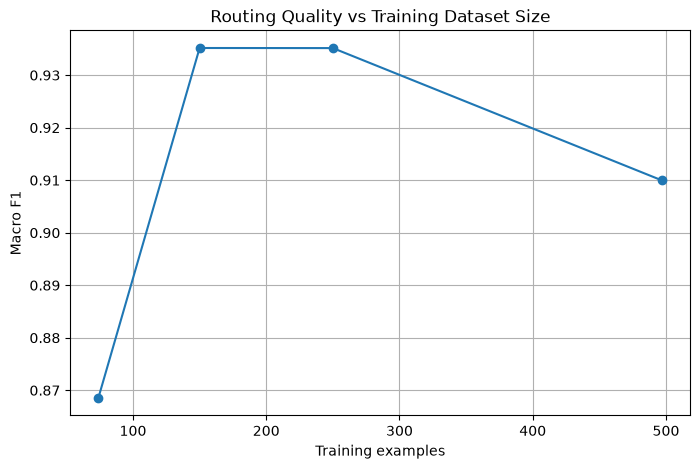

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    scaling_df["training_examples"],
    scaling_df["macro_f1"],
    marker="o",
)

plt.xlabel("Training examples")
plt.ylabel("Macro F1")
plt.title("Routing Quality vs Training Dataset Size")

plt.grid(True)

plt.show()

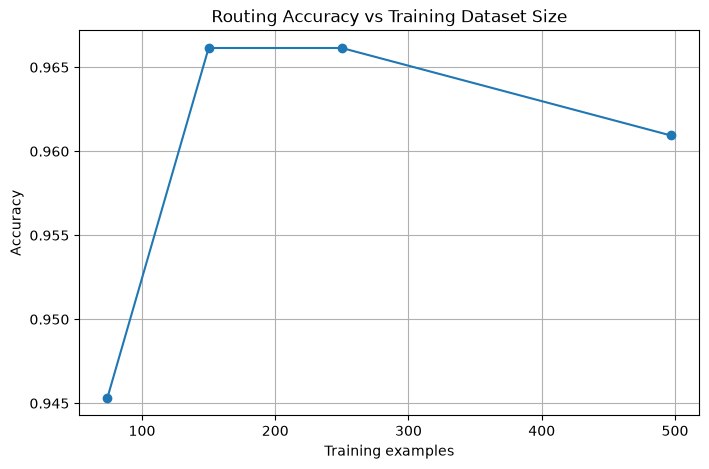

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    scaling_df["training_examples"],
    scaling_df["accuracy"],
    marker="o",
)

plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.title("Routing Accuracy vs Training Dataset Size")

plt.grid(True)

plt.show()

## Initial Scaling Results

Increasing the training set from 74 to 150 examples produced a substantial
improvement in routing quality.

| Training Examples | Accuracy | Macro Precision | Macro Recall | Macro F1 |
| ---: | ---: | ---: | ---: | ---: |
| 74 | 94.53% | 0.908 | 0.847 | 0.869 |
| 150 | **96.61%** | 0.938 | **0.938** | **0.935** |
| 250 | **96.61%** | **0.943** | 0.929 | **0.935** |
| 497 | 96.09% | 0.934 | 0.890 | 0.910 |

The largest gain occurs between 74 and 150 examples. Increasing the dataset to
250 examples produces essentially unchanged macro F1, while using the complete
497-example corpus reduces recall and macro F1.

This suggests that dataset size alone is not sufficient. The additional V3
examples contain many controlled paraphrases of the same underlying scenarios,
so increasing corpus size does not necessarily increase semantic diversity.

However, this experiment also contains an optimization confound: all dataset
sizes were trained for 100 epochs. Larger datasets therefore received more
optimizer updates. A more controlled experiment should compare dataset sizes
under a fixed optimization budget and multiple random seeds before attributing
the difference entirely to dataset composition.

## Controlled Scaling Experiment

The initial scaling experiment trained every dataset size for the same number of
epochs. Because larger datasets contain more examples per epoch, they also
received more optimizer updates.

This experiment removes that confound by fixing the optimization budget.

Each dataset size is trained with:

- BGE Base EN v1.5 frozen encoder
- 128-dimensional learned projection
- TwoTowerDecisionHead with 128 hidden units
- AdamW with learning rate 1e-3
- BCEWithLogitsLoss
- classification threshold 0.5
- exactly 20,000 optimizer updates

Each dataset size is evaluated across three random seeds:

- 42
- 123
- 456

The same deterministic nested training subsets and the same 48-example V3
validation set are used throughout.

In [19]:
CONTROLLED_SEEDS = [
    42,
    123,
    456,
]

MAX_STEPS = 20_000

In [20]:
def train_and_evaluate_fixed_steps(
    subset_size: int,
    seed: int,
    max_steps: int = MAX_STEPS,
    learning_rate: float = 1e-3,
    threshold: float = 0.5,
):
    reset_seed(seed)

    projection = RoutingProjection(
        input_dim=embedding_dim,
        output_dim=128,
    ).to(device)

    head = TwoTowerDecisionHead(
        embedding_dim=128,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(projection.parameters())
        + list(head.parameters()),
        lr=learning_rate,
    )

    criterion = torch.nn.BCEWithLogitsLoss()

    subset_embeddings = training_embeddings[
        :subset_size
    ]

    subset_targets = training_targets[
        :subset_size
    ]

    projection.train()
    head.train()

    loss_history = []

    step = 0

    progress = tqdm(
        total=max_steps,
        desc=f"n={subset_size}, seed={seed}",
    )

    while step < max_steps:
        for state_embedding, targets in zip(
            subset_embeddings,
            subset_targets,
        ):
            if step >= max_steps:
                break

            optimizer.zero_grad()

            projected_state = projection(
                state_embedding
            )

            projected_questions = projection(
                question_embeddings
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            loss = criterion(
                logits,
                targets,
            )

            loss.backward()
            optimizer.step()

            loss_history.append(
                loss.item()
            )

            step += 1
            progress.update(1)

    progress.close()

    projection.eval()
    head.eval()

    probability_rows = []

    with torch.no_grad():
        projected_questions = projection(
            question_embeddings
        )

        for state_embedding in validation_embeddings:
            projected_state = projection(
                state_embedding
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            probabilities = torch.sigmoid(
                logits
            ).cpu()

            probability_rows.append(
                probabilities
            )

    probabilities = torch.stack(
        probability_rows
    )

    predictions = (
        probabilities >= threshold
    ).int()

    accuracy = (
        predictions == validation_targets
    ).float().mean().item()

    metrics = compute_metrics(
        validation_targets,
        predictions,
    )

    result = {
        "subset_size": subset_size,
        "seed": seed,
        "steps": max_steps,
        "accuracy": accuracy,
        "macro_precision": metrics["precision"].mean(),
        "macro_recall": metrics["recall"].mean(),
        "macro_f1": metrics["f1"].mean(),
        "metrics": metrics,
        "loss_history": loss_history,
    }

    del projection
    del head

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [21]:
controlled_results = []

for subset_size in subset_sizes:
    for seed in CONTROLLED_SEEDS:
        result = train_and_evaluate_fixed_steps(
            subset_size=subset_size,
            seed=seed,
        )

        controlled_results.append(
            result
        )

        print(
            f"\n"
            f"size={subset_size}, "
            f"seed={seed}"
        )

        print(
            f"accuracy:        "
            f"{result['accuracy']:.3%}"
        )

        print(
            f"macro precision: "
            f"{result['macro_precision']:.3f}"
        )

        print(
            f"macro recall:    "
            f"{result['macro_recall']:.3f}"
        )

        print(
            f"macro F1:        "
            f"{result['macro_f1']:.3f}"
        )

n=74, seed=42:   0%|          | 0/20000 [00:00<?, ?it/s]


size=74, seed=42
accuracy:        94.010%
macro precision: 0.905
macro recall:    0.818
macro F1:        0.847


n=74, seed=123:   0%|          | 0/20000 [00:00<?, ?it/s]


size=74, seed=123
accuracy:        94.010%
macro precision: 0.961
macro recall:    0.789
macro F1:        0.854


n=74, seed=456:   0%|          | 0/20000 [00:00<?, ?it/s]

...


size=497, seed=42
accuracy:        96.875%
macro precision: 0.960
macro recall:    0.905
macro F1:        0.929


n=497, seed=123:   0%|          | 0/20000 [00:00<?, ?it/s]


size=497, seed=123
accuracy:        96.615%
macro precision: 0.953
macro recall:    0.916
macro F1:        0.929


n=497, seed=456:   0%|          | 0/20000 [00:00<?, ?it/s]


size=497, seed=456
accuracy:        95.833%
macro precision: 0.946
macro recall:    0.878
macro F1:        0.907


In [22]:
controlled_df = pd.DataFrame(
    [
        {
            "training_examples": result["subset_size"],
            "seed": result["seed"],
            "accuracy": result["accuracy"],
            "macro_precision": result["macro_precision"],
            "macro_recall": result["macro_recall"],
            "macro_f1": result["macro_f1"],
        }
        for result in controlled_results
    ]
)

controlled_df

,training_examples,seed,accuracy,macro_precision,macro_recall,macro_f1
0,74,42,0.940104,0.904784,0.817751,0.846729
1,74,123,0.940104,0.960565,0.789251,0.853932
2,74,456,0.945312,0.936632,0.847287,0.878297
3,150,42,0.963542,0.953483,0.917702,0.932903
4,150,123,0.950521,0.911903,0.894388,0.896487
5,150,456,0.955729,0.901242,0.929855,0.909735
6,250,42,0.963542,0.937363,0.928615,0.932520
7,250,123,0.955729,0.919061,0.908547,0.908291
8,250,456,0.963542,0.894066,0.953664,0.918430
9,497,42,0.968750,0.959596,0.905301,0.928655


In [23]:
controlled_summary = (
    controlled_df
    .groupby("training_examples")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("macro_precision", "mean"),
        precision_std=("macro_precision", "std"),
        recall_mean=("macro_recall", "mean"),
        recall_std=("macro_recall", "std"),
        f1_mean=("macro_f1", "mean"),
        f1_std=("macro_f1", "std"),
    )
    .reset_index()
)

controlled_summary

,training_examples,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,74,0.941840,0.003007,0.933994,0.027984,0.818097,0.029019,0.859652,0.016543
1,150,0.956597,0.006554,0.922209,0.027604,0.913982,0.018023,0.913042,0.018431
2,250,0.960938,0.004511,0.916830,0.021735,0.930275,0.022604,0.919747,0.012168
3,497,0.964410,0.005421,0.952942,0.006748,0.899762,0.020051,0.921483,0.012768


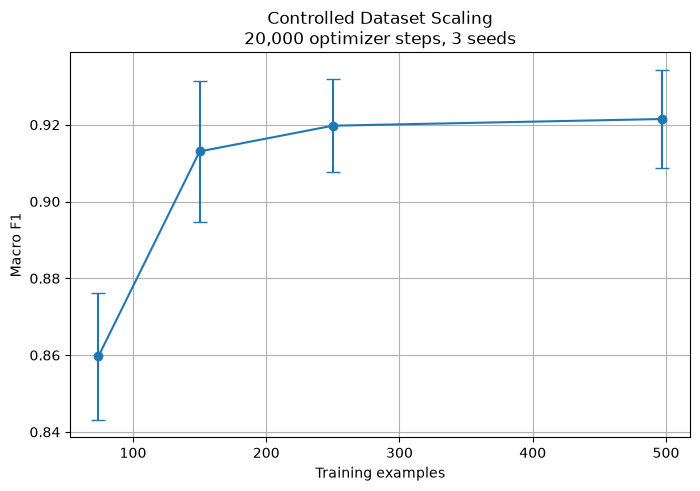

In [24]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    controlled_summary["training_examples"],
    controlled_summary["f1_mean"],
    yerr=controlled_summary["f1_std"],
    marker="o",
    capsize=5,
)

plt.xlabel("Training examples")
plt.ylabel("Macro F1")
plt.title(
    "Controlled Dataset Scaling\n"
    "20,000 optimizer steps, 3 seeds"
)

plt.grid(True)

plt.show()

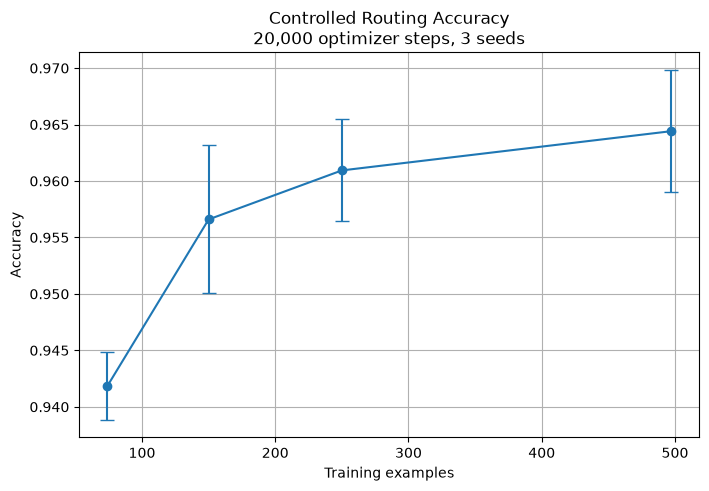

In [25]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    controlled_summary["training_examples"],
    controlled_summary["accuracy_mean"],
    yerr=controlled_summary["accuracy_std"],
    marker="o",
    capsize=5,
)

plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.title(
    "Controlled Routing Accuracy\n"
    "20,000 optimizer steps, 3 seeds"
)

plt.grid(True)

plt.show()

In [26]:
for size in subset_sizes:
    effective_epochs = MAX_STEPS / size

    print(
        f"{size:>3} examples: "
        f"{effective_epochs:>7.2f} effective epochs"
    )

 74 examples:  270.27 effective epochs
150 examples:  133.33 effective epochs
250 examples:   80.00 effective epochs
497 examples:   40.24 effective epochs


## Controlled Scaling Results

Controlling the optimization budget changes the interpretation of the initial
dataset-scaling experiment.

Each dataset size was trained for exactly 20,000 optimizer updates across three
random seeds.

| Training Examples | Mean Accuracy | Accuracy Std | Mean Macro F1 | F1 Std |
| ---: | ---: | ---: | ---: | ---: |
| 74 | 94.18% | 0.003 | 0.860 | 0.017 |
| 150 | 95.66% | 0.007 | 0.913 | 0.018 |
| 250 | 96.09% | 0.005 | 0.920 | 0.012 |
| 497 | **96.44%** | 0.005 | **0.921** | 0.013 |

The largest improvement occurs between 74 and 150 training examples, where
mean macro F1 increases from 0.860 to 0.913.

Increasing the corpus from 150 to 250 examples provides a smaller improvement,
and increasing it from 250 to 497 examples produces only a marginal additional
gain.

The earlier apparent degradation at 497 examples was therefore largely caused
by the fixed-epoch training protocol, which gave larger datasets substantially
more optimizer updates.

Under a fixed optimization budget, the full V3 corpus achieves the highest mean
accuracy and macro F1, although the difference between 250 and 497 examples is
small relative to run-to-run variation.

The results suggest diminishing returns from additional examples drawn from the
current generation strategy. Future dataset expansion should therefore focus
more on new semantic scenarios and capability combinations than on additional
surface-level paraphrases.

### Precision–Recall Tradeoff

The 250-example configuration achieves the highest mean macro recall (0.930),
while the full 497-example corpus achieves the highest mean macro precision
(0.953).

This suggests that the larger training corpus produces a somewhat more
conservative router: it activates capabilities more selectively, reducing false
positives at the cost of additional false negatives.

For agent routing, this tradeoff may matter because failing to enable a required
capability can have a different operational cost from enabling an unnecessary
one. Threshold and cost-sensitive calibration are left for a separate
experiment.

## Full-Corpus Error Analysis

The controlled scaling experiment shows that the complete 497-example V3
training corpus provides the highest mean accuracy and macro F1, although the
improvement over 250 examples is small.

To understand the remaining limitations, the following analysis aggregates
per-capability precision, recall, F1, false positives, and false negatives
across the three 497-example training runs.

This reveals whether the remaining errors are concentrated in particular
capabilities or represent a broader limitation of the routing architecture.

In [27]:
full_results = [
    result
    for result in controlled_results
    if result["subset_size"] == 497
]

len(full_results)

3

In [28]:
per_capability_rows = []

for result in full_results:
    metrics = result["metrics"]

    for _, row in metrics.iterrows():
        per_capability_rows.append(
            {
                "seed": result["seed"],
                "label": row["label"],
                "precision": row["precision"],
                "recall": row["recall"],
                "f1": row["f1"],
                "tp": row["tp"],
                "fp": row["fp"],
                "fn": row["fn"],
                "tn": row["tn"],
            }
        )

per_capability_df = pd.DataFrame(
    per_capability_rows
)

per_capability_df

,seed,label,precision,recall,f1,tp,fp,fn,tn
0,42,needs_filesystem,1.000000,0.857143,0.923077,18,0,3,27
1,42,needs_git,0.888889,1.000000,0.941176,8,1,0,39
2,42,needs_shell,1.000000,0.750000,0.857143,6,0,2,40
3,42,needs_browser,0.833333,0.833333,0.833333,5,1,1,41
4,42,needs_network,0.954545,0.913043,0.933333,21,1,2,24
5,42,needs_database,1.000000,1.000000,1.000000,9,0,0,39
6,42,needs_email,1.000000,0.888889,0.941176,8,0,1,39
7,42,needs_calendar,1.000000,1.000000,1.000000,6,0,0,42
8,123,needs_filesystem,1.000000,0.904762,0.950000,19,0,2,27
9,123,needs_git,1.000000,0.875000,0.933333,7,0,1,40


In [29]:
per_capability_summary = (
    per_capability_df
    .groupby("label")
    .agg(
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        fp_mean=("fp", "mean"),
        fn_mean=("fn", "mean"),
    )
    .reset_index()
)

per_capability_summary = (
    per_capability_summary
    .sort_values(
        "f1_mean",
        ascending=True,
    )
)

per_capability_summary.round(3)

,label,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fp_mean,fn_mean
0,needs_browser,0.766,0.061,0.889,0.096,0.820,0.045,1.667,0.667
7,needs_shell,1.000,0.000,0.750,0.000,0.857,0.000,0.000,2.000
4,needs_filesystem,0.967,0.058,0.873,0.027,0.917,0.036,0.667,2.667
6,needs_network,0.928,0.046,0.913,0.000,0.920,0.023,1.667,2.000
3,needs_email,1.000,0.000,0.889,0.000,0.941,0.000,0.000,1.000
5,needs_git,0.963,0.064,0.958,0.072,0.958,0.036,0.333,0.333
2,needs_database,1.000,0.000,0.926,0.128,0.958,0.072,0.000,0.667
1,needs_calendar,1.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000


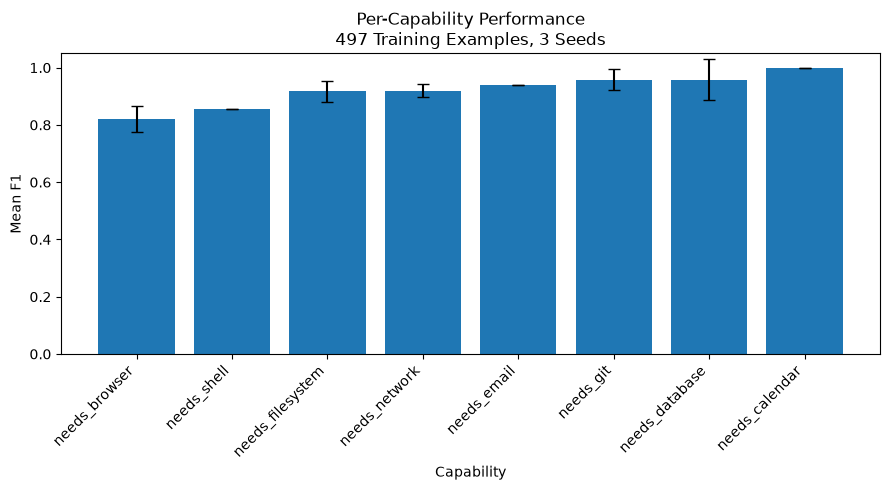

In [30]:
plt.figure(figsize=(9, 5))

plt.bar(
    per_capability_summary["label"],
    per_capability_summary["f1_mean"],
    yerr=per_capability_summary["f1_std"],
    capsize=4,
)

plt.ylabel("Mean F1")
plt.xlabel("Capability")
plt.title(
    "Per-Capability Performance\n"
    "497 Training Examples, 3 Seeds"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [31]:
error_summary = per_capability_summary[
    [
        "label",
        "fp_mean",
        "fn_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
    ]
].copy()

error_summary.round(3)

,label,fp_mean,fn_mean,precision_mean,recall_mean,f1_mean
0,needs_browser,1.667,0.667,0.766,0.889,0.820
7,needs_shell,0.000,2.000,1.000,0.750,0.857
4,needs_filesystem,0.667,2.667,0.967,0.873,0.917
6,needs_network,1.667,2.000,0.928,0.913,0.920
3,needs_email,0.000,1.000,1.000,0.889,0.941
5,needs_git,0.333,0.333,0.963,0.958,0.958
2,needs_database,0.000,0.667,1.000,0.926,0.958
1,needs_calendar,0.000,0.000,1.000,1.000,1.000


In [32]:
error_summary["mean_errors"] = (
    error_summary["fp_mean"]
    + error_summary["fn_mean"]
)

error_summary = error_summary.sort_values(
    "mean_errors",
    ascending=False,
)

error_summary.round(3)

,label,fp_mean,fn_mean,precision_mean,recall_mean,f1_mean,mean_errors
6,needs_network,1.667,2.000,0.928,0.913,0.920,3.667
4,needs_filesystem,0.667,2.667,0.967,0.873,0.917,3.333
0,needs_browser,1.667,0.667,0.766,0.889,0.820,2.333
7,needs_shell,0.000,2.000,1.000,0.750,0.857,2.000
3,needs_email,0.000,1.000,1.000,0.889,0.941,1.000
5,needs_git,0.333,0.333,0.963,0.958,0.958,0.667
2,needs_database,0.000,0.667,1.000,0.926,0.958,0.667
1,needs_calendar,0.000,0.000,1.000,1.000,1.000,0.000


## Per-Capability Error Analysis

The 497-example configuration was evaluated across three random seeds to identify
which capabilities account for the remaining routing errors.

| Capability | Mean Precision | Mean Recall | Mean F1 | Mean FP | Mean FN |
| --- | ---: | ---: | ---: | ---: | ---: |
| Browser | 0.766 | 0.889 | 0.820 | 1.667 | 0.667 |
| Shell | 1.000 | 0.750 | 0.857 | 0.000 | 2.000 |
| Filesystem | 0.967 | 0.873 | 0.917 | 0.667 | 2.667 |
| Network | 0.928 | 0.913 | 0.920 | 1.667 | 2.000 |
| Email | 1.000 | 0.889 | 0.941 | 0.000 | 1.000 |
| Git | 0.963 | 0.958 | 0.958 | 0.333 | 0.333 |
| Database | 1.000 | 0.926 | 0.958 | 0.000 | 0.667 |
| Calendar | 1.000 | 1.000 | 1.000 | 0.000 | 0.000 |

### Observations

Browser routing has the lowest mean F1. Its main weakness is precision rather
than recall, indicating that the router sometimes enables browser access for
requests that can be handled without opening a web page.

Shell routing shows the opposite pattern. Precision is perfect across all three
runs, but recall remains fixed at 0.75. The router is therefore conservative
about enabling shell execution and consistently misses some executable tasks.

Filesystem and network account for the largest total number of errors. Both
capabilities are common secondary requirements in multi-step workflows, which
makes them particularly sensitive to compositional requests.

Email also remains conservative: precision is perfect, but one positive email
case is missed consistently across all three seeds.

Git and database routing are strong and stable. Calendar routing is perfect on
the current V3 validation set across all seeds.

The consistency of several errors across random seeds suggests that these
failure modes are primarily associated with dataset coverage or representation
rather than random initialization.

Future data collection should therefore emphasize genuinely new browser,
shell, filesystem, network, and email scenarios rather than additional
surface-level paraphrases of existing examples.